# Virtualizing HRRR hourly surface data

HRRR `wrfsfc` files pack many different level types and product kinds into a single GRIB2 file. `gribberish` mirrors `cfgrib` and splits these into nested groups (e.g. `sfc/instant`, `hag/instant`, `isobar/instant`), so the natural VirtualiZarr representation is a *virtual `DataTree`* rather than a single flat dataset.

We open the file as a virtual `DataTree`, persist it to an Icechunk repository, and reopen it lazily.

In [1]:
import virtualizarr as vz

from obstore.store import from_url
from obspec_utils.registry import ObjectStoreRegistry
from gribberish.virtualizarr import GribberishParser

## Open the file as a virtual `DataTree`

Because a single HRRR surface file resolves to many groups, we use `open_virtual_datatree` (the grouped counterpart of `open_virtual_dataset`).

In [3]:
%%time

parser = GribberishParser(use_index=".idx")

bucket = 's3://noaa-hrrr-bdp-pds'
store = from_url(bucket, region="us-east-1", skip_signature=True)
registry = ObjectStoreRegistry({bucket: store})

url = f'{bucket}/hrrr.20260609/conus/hrrr.t01z.wrfsfcf01.grib2'

vdt = vz.open_virtual_datatree(
    url,
    parser=parser,
    registry=registry,
)

vdt

CPU times: user 507 ms, sys: 97.2 ms, total: 605 ms
Wall time: 1.09 s


<xarray.DataTree>
Group: /
│   Attributes:
│       meta:     Generated with gribberishpy
├── Group: /adiabatic_condensation_lifted
│   │   Attributes:
│   │       meta:     Generated with gribberishpy
│   └── Group: /adiabatic_condensation_lifted/instant
│           Dimensions:      (time: 1, y: 1059, x: 1799)
│           Coordinates:
│             * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│             * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│             * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│               latitude     (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
│               longitude    (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
│               spatial_ref  int64 8B ManifestArray<shape=(), dtype=int64, chunks=()>
│           Data variables:
│               hgt          (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│           Attributes:
│               meta:     Generated with gribberishpy
├── Group: /atm
│   │   Attributes:
│   │       meta:     Generated with gribberishpy
│   ├── Group: /atm/instant
│   │       Dimensions:      (time: 1, y: 1059, x: 1799)
│   │       Coordinates:
│   │         * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│   │         * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│   │         * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│   │           latitude     (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
│   │           longitude    (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
│   │           spatial_ref  int64 8B ManifestArray<shape=(), dtype=int64, chunks=()>
│   │       Data variables:
│   │           ltng         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│   │           tcoli        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│   │           tcolw        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│   │           rhpw         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│   │           tcdc         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│   │           veril        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│   │           refc         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│   │       Attributes:
│   │           meta:     Generated with gribberishpy
│   └── Group: /atm/max1h
│           Dimensions:      (time: 1, y: 1059, x: 1799)
│           Coordinates:
│             * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│             * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│             * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│               latitude     (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
│               longitude    (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
│               spatial_ref  int64 8B ManifestArray<shape=(), dtype=int64, chunks=()>
│           Data variables:
│               hail         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
│           Attributes:
│               meta:     Generated with gribberishpy
├── Group: /bndry_cloud
│   │   Attributes:
│   │       meta:     Generated with gribberishpy
│   └── Group: /bndry_cloud/instant
│           Dimensions:      (time: 1, y: 1059, x: 1799)
│           Coordinates:
│             * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│             * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│             * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│               latitude     (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
│               longitude    (y, x) float64 15MB Manife

Each group is a self-contained virtual dataset. For example, the instantaneous surface fields live under `sfc/instant`:

In [3]:
vdt['/sfc/instant']

<xarray.DataTree 'instant'>
Group: /sfc/instant
    Dimensions:      (time: 1, y: 1059, x: 1799)
    Coordinates:
      * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
      * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
      * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
        latitude     (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
        longitude    (y, x) float64 15MB ManifestArray<shape=(1059, 1799), dtype=...
        spatial_ref  int64 8B ManifestArray<shape=(), dtype=int64, chunks=()>
    Data variables: (12/38)
        dswrf        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        pres         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        lhtfl        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        snod         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        vis          (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        cin          (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        ...           ...
        vddsf        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        gust         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        crain        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        ulwrf        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        sfcr         (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
        cfrzr        (time, y, x) float64 15MB ManifestArray<shape=(1, 1059, 1799...
    Attributes:
        meta:     Generated with gribberishpy

## Persist the virtual references to Icechunk

We register the HRRR bucket as a virtual chunk container so Icechunk can read the original GRIB2 bytes on demand, then write the whole virtual `DataTree` in one commit.

In [4]:
import icechunk

config = icechunk.RepositoryConfig.default()

config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix="s3://noaa-hrrr-bdp-pds/",
        store=icechunk.s3_store(
            region="us-east-1",
            anonymous=True,
        ),
    )
)

storage = icechunk.local_filesystem_storage("hrrr-hourly.icechunk")
repo = icechunk.Repository.create(storage, config)
repo

  2026-06-11T13:56:05.030924Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



<icechunk.Repository (v2)>
storage:
    <icechunk.Storage>
    type: local filesystem
    path: hrrr-hourly.icechunk
config: <RepositoryConfig ...>

In [5]:
session = repo.writable_session("main")

vdt.vz.to_icechunk(session.store)

snapshot_id = session.commit("Virtualized HRRR hourly surface")
repo.save_config()

snapshot_id

'SJ0JN84PXJN02Z7B0400'

## Reopen and use the data

Reopen the repository and load the `DataTree`. Reading any variable pulls the corresponding GRIB2 message straight from S3 and decodes it with the `gribberish` zarr codec.

In [6]:
import xarray as xr

repo = icechunk.Repository.open(
    storage=icechunk.local_filesystem_storage("hrrr-hourly.icechunk"),
    authorize_virtual_chunk_access={
        "s3://noaa-hrrr-bdp-pds/": None,
    },
)

session = repo.readonly_session("main")

dt = xr.open_datatree(session.store, engine="zarr", consolidated=False)
dt

  2026-06-11T13:56:09.188370Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



<xarray.DataTree>
Group: /
│   Attributes:
│       meta:     Generated with gribberishpy
├── Group: /depth_bls
│   │   Attributes:
│   │       meta:     Generated with gribberishpy
│   └── Group: /depth_bls/instant
│           Dimensions:      (time: 1, y: 1059, x: 1799)
│           Coordinates:
│             * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│             * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│             * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│               latitude     (y, x) float64 15MB ...
│               longitude    (y, x) float64 15MB ...
│               spatial_ref  int64 8B ...
│           Data variables:
│               mstav        (time, y, x) float64 15MB ...
│           Attributes:
│               meta:     Generated with gribberishpy
├── Group: /adiabatic_condensation_lifted
│   │   Attributes:
│   │       meta:     Generated with gribberishpy
│   └── Group: /adiabatic_condensation_lifted/instant
│           Dimensions:      (time: 1, y: 1059, x: 1799)
│           Coordinates:
│             * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│             * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│             * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│               longitude    (y, x) float64 15MB ...
│               latitude     (y, x) float64 15MB ...
│               spatial_ref  int64 8B ...
│           Data variables:
│               hgt          (time, y, x) float64 15MB ...
│           Attributes:
│               meta:     Generated with gribberishpy
├── Group: /clb
│   │   Attributes:
│   │       meta:     Generated with gribberishpy
│   └── Group: /clb/instant
│           Dimensions:      (time: 1, y: 1059, x: 1799)
│           Coordinates:
│             * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│             * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│             * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│               longitude    (y, x) float64 15MB ...
│               latitude     (y, x) float64 15MB ...
│               spatial_ref  int64 8B ...
│           Data variables:
│               hgt          (time, y, x) float64 15MB ...
│               pres         (time, y, x) float64 15MB ...
│           Attributes:
│               meta:     Generated with gribberishpy
├── Group: /entire_atm
│   │   Attributes:
│   │       meta:     Generated with gribberishpy
│   ├── Group: /entire_atm/instant
│   │       Dimensions:      (time: 1, y: 1059, x: 1799)
│   │       Coordinates:
│   │         * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│   │         * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│   │         * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│   │           longitude    (y, x) float64 15MB ...
│   │           latitude     (y, x) float64 15MB ...
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           apts         (time, y, x) float64 15MB ...
│   │           colmd        (time, y, x) float64 15MB ...
│   │           pwat         (time, y, x) float64 15MB ...
│   │       Attributes:
│   │           meta:     Generated with gribberishpy
│   └── Group: /entire_atm/max1h
│           Dimensions:      (time: 1, y: 1059, x: 1799)
│           Coordinates:
│             * time         (time) datetime64[ns] 8B 2026-06-09T02:00:00
│             * y            (y) float64 8kB -1.587e+06 -1.584e+06 ... 1.584e+06 1.587e+06
│             * x            (x) float64 14kB -2.698e+06 -2.695e+06 ... 2.693e+06 2.696e+06
│               latitude     (y, x) float64 15MB ...
│               longitude    (y, x) float64 15MB ...
│               spatial_ref  int64 8B ...
│           Data variables:
│               tcolg        (time, y, x) fl

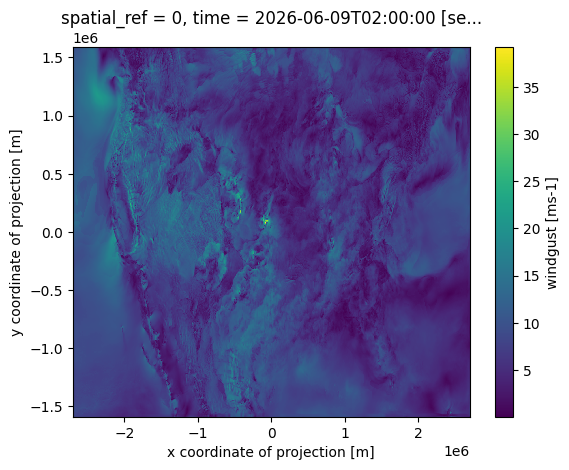

In [7]:
dt['/sfc/instant'].gust.isel(time=0).plot()